# 1. Problem Definition

Air pollution is a big problem in the city of Tabriz. One of the most harmful
parts of air pollution is PM2.5, which are very small particles that are bad
for people's health. Measuring PM2.5 needs special sensors, but weather data
like temperature and wind is easy to get.

So in this project we want to answer this question: can we tell if the pollution
is high or low just from the weather conditions?

Our goal is to build a model that takes the weather conditions and predicts if
the pollution level is High or Low. This is a classification problem, because
the answer we want is a class (High or Low), not a number.

# 2. Dataset Selection

We used a public dataset from Kaggle called "Tabriz Air Pollution DataSet".

Source: https://www.kaggle.com/datasets/sabermalek/tapds

The data has hourly readings of weather and pollution in the city of Tabriz.

**Features (the inputs):**

* air_temperature : the temperature of the air
* dewpoint : tells how humid the air is
* wind_direction : the direction of the wind (0 to 360 degrees)
* wind_speed : how fast the wind is


**Target (what we predict):**

* Pollution : High (1) if PM2.5 is above the median, or Low (0) if it is below
* Number of samples: around 16,000 rows (each row is one hour).

# 3. Exploratory Data Analysis (EDA)

**

In [99]:
# Importing necessary libararies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

## 1.1 Import Dataset

In [100]:
abrasan_df = pd.read_csv("/kaggle/input/datasets/sabermalek/tapds/TabrizPollution/Abrasan.csv",delimiter=';')
bashumal_df = pd.read_csv("/kaggle/input/datasets/sabermalek/tapds/TabrizPollution/Bashumal.csv",delimiter=";")
rastakucha_df = pd.read_csv("/kaggle/input/datasets/sabermalek/tapds/TabrizPollution/RastaKucha.csv",delimiter=';')

df = pd.concat([abrasan_df,bashumal_df,rastakucha_df])

In [101]:
df.head()

,Time,air_temperature,dewpoint,wind_direction_corr,wind_speed,relative_pressure,PM10,PM2.5
0,02/19/2017 10:30,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,77.96,46.47
1,02/19/2017 11:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,15.22,14.62
2,02/19/2017 11:30,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,8.68,8.35
3,02/19/2017 12:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,6.92,6.70
4,02/19/2017 12:30,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,5.89,5.72


In [102]:
df.drop(['Time'],axis=1,inplace=True)
print("Shape:", df.shape)

Shape: (48962, 7)


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48962 entries, 0 to 16467
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   air_temperature      48962 non-null  float64
 1   dewpoint             48962 non-null  float64
 2   wind_direction_corr  48962 non-null  float64
 3   wind_speed           48962 non-null  float64
 4   relative_pressure    48962 non-null  float64
 5   PM10                 48962 non-null  float64
 6   PM2.5                48962 non-null  float64
dtypes: float64(7)
memory usage: 3.0 MB


In [104]:
df.describe()

,air_temperature,dewpoint,wind_direction_corr,wind_speed,relative_pressure,PM10,PM2.5
count,48962.000000,48962.000000,48962.000000,48962.000000,48962.000000,48962.000000,48962.000000
mean,-48.641823,-62.397421,56.498420,-63.514204,789.289590,-1057.925704,-1089.109561
std,800.761921,798.333925,822.654039,798.226238,866.753414,3157.658804,3146.215129
min,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,7.510000,-2.270000,35.270000,0.190000,855.590000,20.510000,9.540000
50%,15.070000,1.580000,100.895000,0.410000,858.800000,40.025000,15.020000
75%,23.410000,5.840000,173.417500,0.820000,862.070000,65.180000,24.540000
max,41.180000,15.290000,359.990000,4.780000,875.230000,1999.230000,253.220000


In [105]:
df.dtypes

air_temperature        float64
dewpoint               float64
wind_direction_corr    float64
wind_speed             float64
relative_pressure      float64
PM10                   float64
PM2.5                  float64
dtype: object

## 1.2 Dataset Preprocessing

In [106]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 air_temperature        0
dewpoint               0
wind_direction_corr    0
wind_speed             0
relative_pressure      0
PM10                   0
PM2.5                  0
dtype: int64


In [107]:
print("\nNumber of duplicated values:\n", df.duplicated().sum())


Number of duplicated values:
 67


In [108]:
# Before: Shape: (48962, 7)

df.drop_duplicates(inplace=True,ignore_index=True)
print("\nAfter removing duplicates, the shape is:\n", df.shape)


After removing duplicates, the shape is:
 (48895, 7)


In [109]:
df

,air_temperature,dewpoint,wind_direction_corr,wind_speed,relative_pressure,PM10,PM2.5
0,-9999.00,-9999.00,-9999.00,-9999.00,-9999.00,77.96,46.47
1,-9999.00,-9999.00,-9999.00,-9999.00,-9999.00,15.22,14.62
2,-9999.00,-9999.00,-9999.00,-9999.00,-9999.00,8.68,8.35
3,-9999.00,-9999.00,-9999.00,-9999.00,-9999.00,6.92,6.70
4,-9999.00,-9999.00,-9999.00,-9999.00,-9999.00,5.89,5.72
...,...,...,...,...,...,...,...
48890,-1.69,-10.26,113.89,0.44,858.13,41.42,32.55
48891,-1.35,-10.62,153.70,0.53,857.90,41.56,27.67
48892,-1.05,-10.45,113.83,0.18,857.91,49.78,31.70
48893,-0.46,-10.02,84.53,0.22,857.96,53.08,35.07


In [110]:
df = df.reset_index(drop=True)
df.shape

(48895, 7)

In [111]:
numeric_cols = df.select_dtypes(include=np.number).columns

outliers = pd.Series(False, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = outliers | (df[col] < lower) | (df[col] > upper)

outliers.sum()

np.int64(11678)

In [112]:
if outliers.sum() > 0:
    df = df[~outliers]

In [113]:
float_cols = df.select_dtypes(include=['float64', 'float32']).columns
df[float_cols] = df[float_cols].astype(int)
df.head()

,air_temperature,dewpoint,wind_direction_corr,wind_speed,relative_pressure,PM10,PM2.5
257,5,-2,24,0,859,108,44
258,4,-4,99,0,859,131,42
303,9,-1,42,0,860,110,42
304,8,-2,54,0,861,110,35
325,8,-4,30,1,860,99,40


In [114]:
X = df.drop('PM2.5', axis=1)
y = df['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=6,
    shuffle=True
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

print("Training Shape:\n", X_train.shape)
print("Testing Shape:\n", X_test.shape)

Training Shape:
 (29773, 6)
Testing Shape:
 (7444, 6)


In [115]:
df

,air_temperature,dewpoint,wind_direction_corr,wind_speed,relative_pressure,PM10,PM2.5
257,5,-2,24,0,859,108,44
258,4,-4,99,0,859,131,42
303,9,-1,42,0,860,110,42
304,8,-2,54,0,861,110,35
325,8,-4,30,1,860,99,40
...,...,...,...,...,...,...,...
48890,-1,-10,113,0,858,41,32
48891,-1,-10,153,0,857,41,27
48892,-1,-10,113,0,857,49,31
48893,0,-10,84,0,857,53,35


In [116]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,air_temperature,dewpoint,wind_direction_corr,wind_speed,relative_pressure,PM10
19434,0.552890,0.668658,0.178698,-0.388362,-0.806515,-0.403884
41229,-1.090262,0.263337,-1.247255,-0.388362,-0.357837,-0.403884
8309,-1.603746,-2.168591,-0.699606,-0.388362,-0.357837,0.285662
46830,-0.063292,-0.344645,0.292360,2.574915,1.885556,-0.901890
41704,-0.679474,-0.344645,-0.864934,-0.388362,-0.133497,1.932911


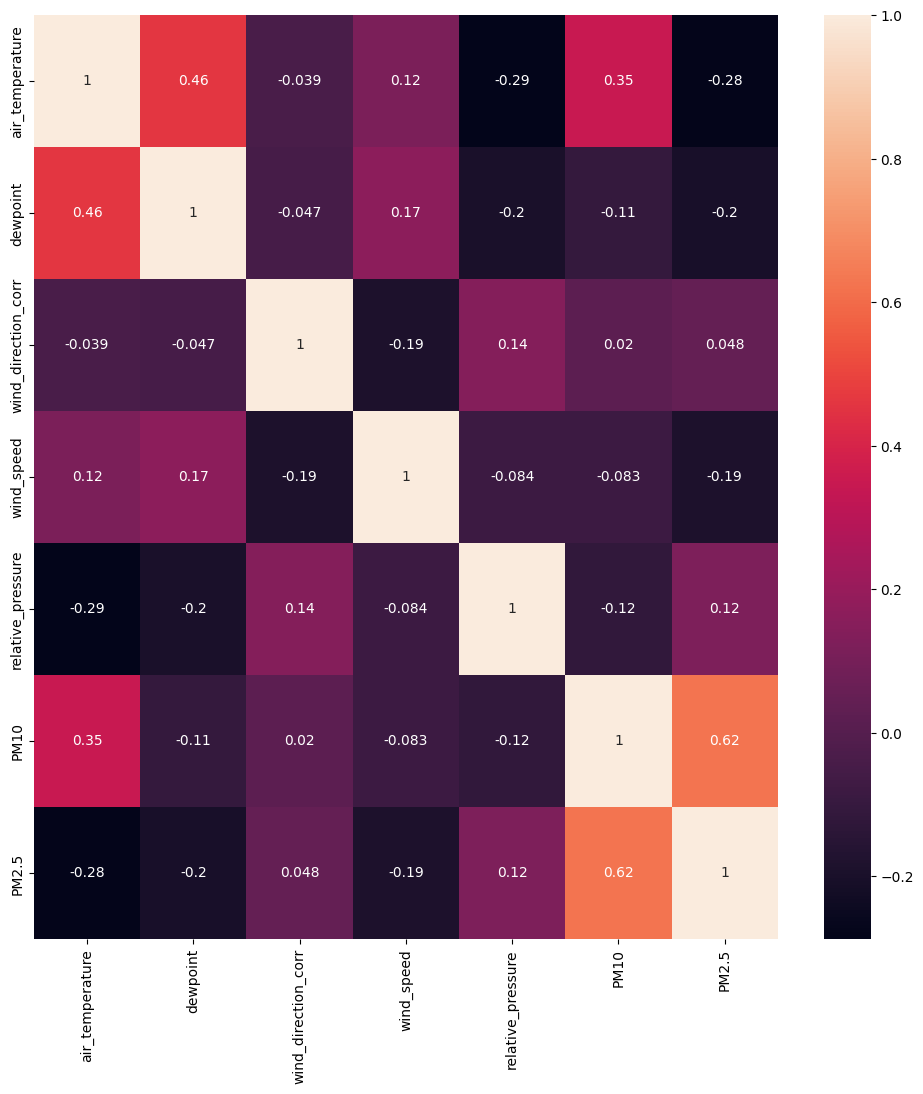

In [117]:
df_clean = df.copy()

plt.figure(figsize=(12,12))
sns.heatmap(df_clean.corr(),annot=True)
plt.show()

In [118]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

In [119]:
print("Decision Tree Results")
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))

Decision Tree Results
R2 Score: 0.6893648169694406
MSE: 28.11176786673831


In [120]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [121]:
print("Random Forest Results")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest Results
R2 Score: 0.810015317802636
MSE: 17.193175711982803


In [122]:
import pickle

with open("airPollution_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)